# FraudGuard AI — Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the transaction dataset and
identify patterns associated with fraudulent and legitimate transactions.

We will investigate:

- Class distribution
- Transaction amount distribution
- Fraud vs legitimate transaction amounts
- Transaction time patterns
- Relationships between numerical features and fraud

### Observation

The target variable is extremely imbalanced.

Legitimate transactions account for approximately 99.83% of the dataset,
while fraudulent transactions represent only approximately 0.17%.

Therefore, accuracy alone will not be sufficient for evaluating the fraud
detection model.

# EDA Summary

## Key Findings

1. The target variable is severely imbalanced, with fraudulent transactions
   representing only a very small fraction of all transactions.

2. Transaction amounts are highly skewed and contain extreme values.

3. Fraudulent and legitimate transactions show differences in their amount
   distributions.

4. Transaction activity varies across the observed time period.

5. Some anonymized PCA features show stronger relationships with the fraud
   target than others.

## Implications for Modeling

- Accuracy alone should not be used to evaluate the model.
- Class imbalance must be considered during training and evaluation.
- `Amount` and `Time` may require preprocessing.
- Feature relationships should be investigated further before feature
  selection.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
class_count=df["Class"].value_counts().sort_index()
class_count



Class
0    284315
1       492
Name: count, dtype: int64

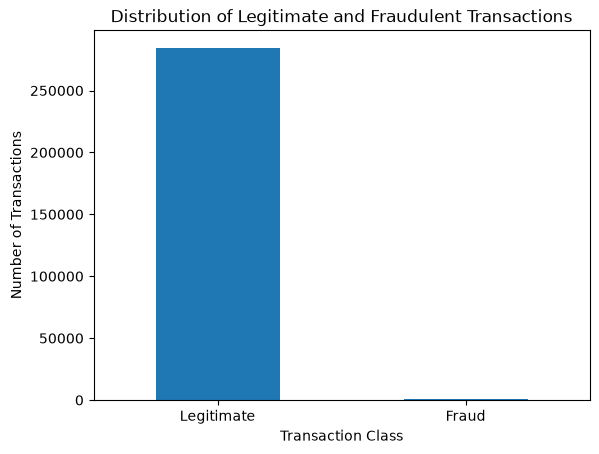

In [14]:
class_count.plot(kind="bar")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)

plt.show()

In [15]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

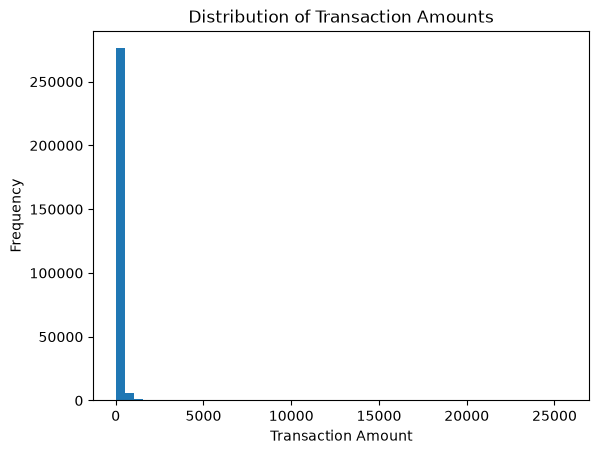

In [16]:
plt.hist(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [20]:
legitimate = df[df["Class"]==0]
fraud = df[df["Class"] == 1]
print(legitimate.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [27]:
print(legitimate["Amount"].describe())
print(fraud["Amount"].describe())

print("legitimate mean:",legitimate["Amount"].mean())
print("fraud mean:",fraud["Amount"].mean())

print("legitimate median:",legitimate["Amount"].median())
print("fraud median:",fraud["Amount"].median())

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
legitimate mean: 88.29102242231328
fraud mean: 122.21132113821139
legitimate median: 22.0
fraud median: 9.25


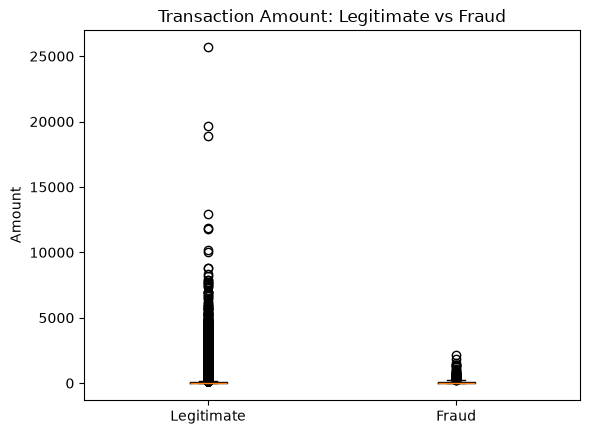

In [29]:
plt.boxplot(
    [
        legitimate["Amount"],
        fraud["Amount"]
    ],
    tick_labels=["Legitimate", "Fraud"]
)

plt.title("Transaction Amount: Legitimate vs Fraud")
plt.ylabel("Amount")

plt.show()

In [30]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

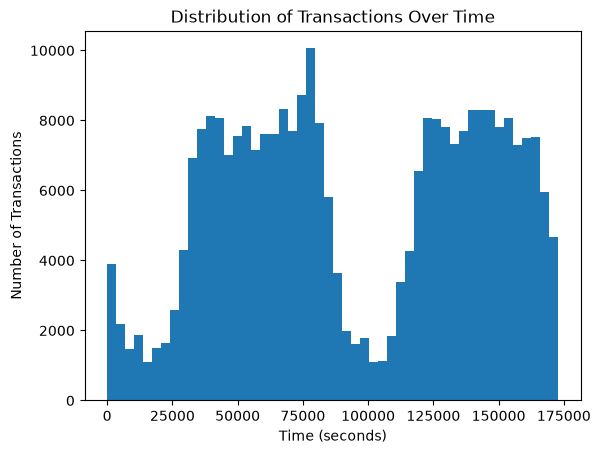

In [31]:
plt.hist(df["Time"], bins=50)

plt.title("Distribution of Transactions Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.show()

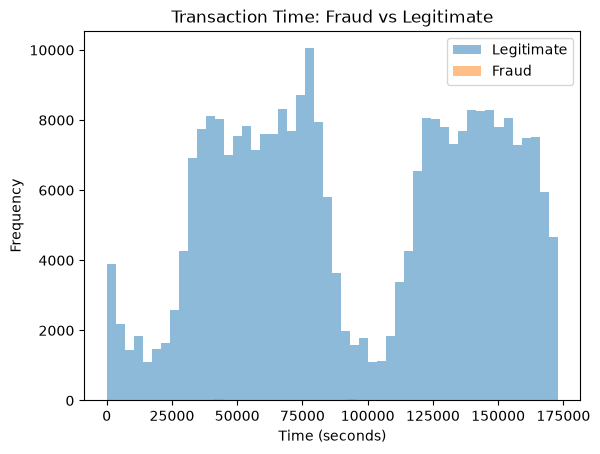

In [32]:
plt.hist(
    legitimate["Time"],
    bins=50,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    fraud["Time"],
    bins=50,
    alpha=0.5,
    label="Fraud"
)

plt.title("Transaction Time: Fraud vs Legitimate")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [6]:
correlations = df.corr(numeric_only=True)["Class"].sort_values()

correlations

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64